In [31]:
%%time
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

import pandas as pd
import wandb
import pandas as pd
from collections import defaultdict

# Table processing
def process_line(means, highlight, highlight_index, highlight_max, ignore_std):
    if highlight:
        if highlight_max:
            tops = set(means.groupby(highlight_index).idxmax())
        else:
            tops = set(means.groupby(highlight_index).idxmin())
    else:
        tops = set()

    def process_line(x):
        if ignore_std:
            if x.name in tops:
                return rf"\textbf{{{x['mean']:0.3f}}}"
            return rf"{x['mean']:0.3f}"
        if x.name in tops:
            return rf"\textbf{{{x['mean']:0.3f} $\pm$ {x['std']:0.3f}}}"
        return rf"{x['mean']:0.3f} $\pm$ {x['std']:0.3f}"

    return process_line


def mean_pm_std(
    data,
    index,
    columns,
    value,
    highlight=True,
    highlight_cols=True,
    highlight_max=True,
    ignore_std=False,
):
    assert len(data) > 0
    groupby = data.groupby([*index, *columns])
    means = groupby.mean()[value].rename("mean")
    stds = groupby.std()[value].rename("std")
    ddf = pd.concat([means, stds], axis=1).T
    highlight_index = columns if highlight_cols else index
    ddf = ddf.apply(
        process_line(means, highlight, highlight_index, highlight_max, ignore_std)
    )
    ddf = ddf.reset_index().pivot(index=index, columns=columns)
    ddf.columns = ddf.columns.droplevel(level=0)
    
    return ddf

    
def flatten_dict(d, parent_key="", sep="/"):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def prepare_data(data):
    flattened_data = [flatten_dict(item) for item in data]
    return pd.DataFrame(flattened_data)



The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CPU times: user 524 μs, sys: 456 μs, total: 980 μs
Wall time: 630 μs


In [32]:
api = wandb.Api(timeout=30)

# Project is specified by <entity/project-name>
runs = api.runs(
    "openproblems-comp/fast-tbg",
    filters={
        "$and": [
            {
                # "created_at": {"$gt": "2025-01-26T00:00:00"},
                "tags": {"$in": ["jarz_rs_v2"]},
                #'group': {'$in': ['5_vars']},
                # "config.data.n_particles": {"$eq": 22},
                #'config.model': {'$eq': model},
                #'config.lr': {'$lt': 1.01 * lr, '$gt': 0.99 * lr},
            }
        ]
    },
)

summary_list, config_list, name_list, tag_list = [], [], [], []
for run in runs:
    tag_list.append(run.tags)
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files
    summary_list.append(run.summary._json_dict)
    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
    # .name is the human-readable name of the run.
    name_list.append(run.name)
df_summary = prepare_data(summary_list)
df_config = prepare_data(config_list)
tag_list = [str(t) for t in tag_list]
df = pd.concat(
    [
        pd.DataFrame(name_list, columns=["name"]),
        pd.DataFrame(tag_list, columns=["Tags"]),
        df_summary,
        df_config,
    ],
    axis=1,
)

In [33]:
metrics = [
    "test/cropped_energy_w1",
    "test/rama/torus_wasserstein",
    "test/resampled/energy_w1",
    "test/resampled/rama/torus_wasserstein",
    "test/jarzynski/energy_w1",
    "test/jarzynski/rama/torus_wasserstein",
    "test/jarzynski/effective_sample_size",
    "test/jarzynski/rama/torus_wasserstein",
]

In [34]:
import math


def filterer(x):
    if isinstance(x, float) and not math.isfinite(x):
        return False
    return "table" in list(x)


filtered_df = df[
    # df["model/_target_"].isin(["src.models.flow_matching_module.FlowMatchLitModule"])
    # & df["Tags"].apply(lambda x: "eval" in x)
    df["Tags"].apply(lambda x: True)
    # & ~df["val/cropped_energy_w1"].isna()
    # & df["tags"].apply(filterer)
][
    [
        # "tags",
        "model/_target_",
        "model/net/_target_",
        "data/n_particles",
        "model/jarzynski_sampler/ess_threshold",
        "model/use_com_energy",
        *metrics,
    ]
].drop(
    columns=["model/_target_"]
)

# filtered_df.sort_values("data/n_particles")

In [35]:
renamed_df = filtered_df.replace(
    {
        "src.models.components.tbg.egnn_dynamics_ad2_cat.EGNN_dynamics_AD2_cat": "EQ-CFM",
        "src.models.components.dit.DIT3D": "DiT-CFM",
        "src.models.components.tarflow.TarFlow": "TarFlow",
    }
).rename(
    columns={
        "model/net/_target_": "Model",
        "data/n_particles": "n_particles",
        "model/jarzynski_sampler/ess_threshold": "ess_threshold",
    }
)

In [36]:
renamed_df.groupby(["Model", "n_particles"]).count()

,,ess_threshold,model/use_com_energy,test/cropped_energy_w1,test/rama/torus_wasserstein,test/resampled/energy_w1,test/resampled/rama/torus_wasserstein,test/jarzynski/energy_w1,test/jarzynski/rama/torus_wasserstein,test/jarzynski/effective_sample_size,test/jarzynski/rama/torus_wasserstein
Model,n_particles,,,,,,,,,,
TarFlow,33,15,15,12,12,12,12,12,12,12,12


In [37]:
renamed_df = renamed_df.drop(columns=["Model"])

renamed_df["test/jarzynski/energy_w1"].dtype

dtype('float64')

1


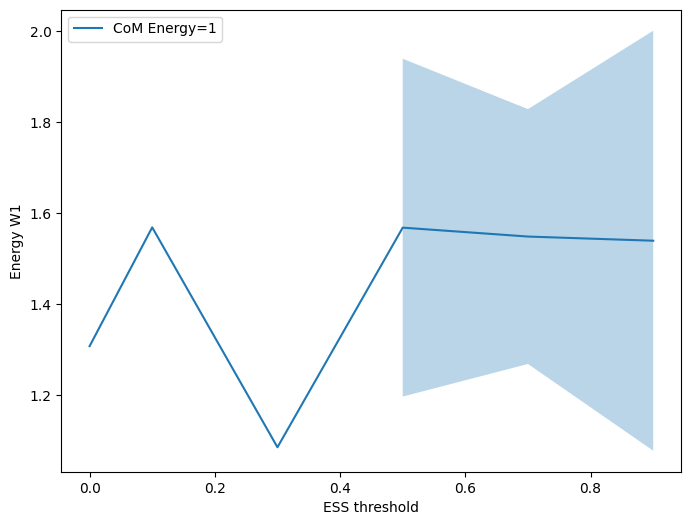

In [38]:
import matplotlib.pyplot as plt

for n_particles in [33]:

    plt.figure(figsize=(8, 6))
    for use_com_energy in renamed_df["model/use_com_energy"].unique():
        particles_df = renamed_df[
            (renamed_df["n_particles"] == n_particles)
            & (renamed_df["model/use_com_energy"] == use_com_energy)
        ]

        particles_df = particles_df.groupby(["ess_threshold"])
        means = particles_df.mean()["test/jarzynski/energy_w1"]
        stds = particles_df.std()["test/jarzynski/energy_w1"]

        plt.plot(
            means.index,
            means,
            label=f"CoM Energy={use_com_energy}",
        )
        plt.fill_between(
            means.index,
            means - stds,
            means + stds,
            alpha=0.3,
        )
    plt.xlabel("ESS threshold")
    plt.ylabel("Energy W1")

    plt.legend()
    plt.show()

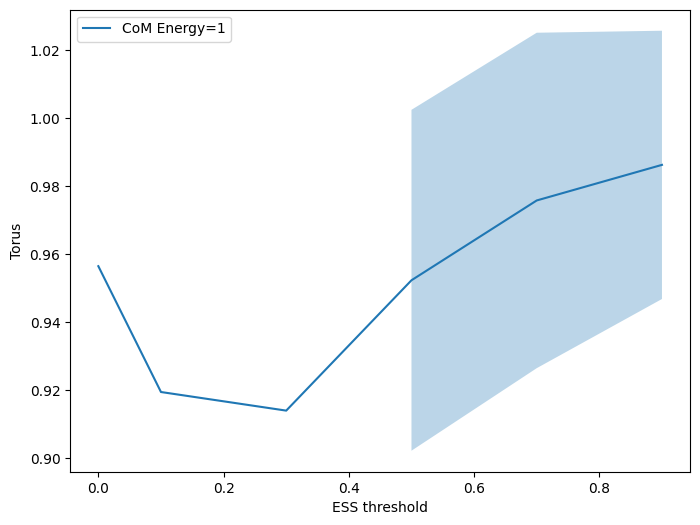

In [30]:
import matplotlib.pyplot as plt

for n_particles in [33]:

    plt.figure(figsize=(8, 6))
    for use_com_energy in renamed_df["model/use_com_energy"].unique():
        particles_df = renamed_df[
            (renamed_df["n_particles"] == n_particles)
            & (renamed_df["model/use_com_energy"] == use_com_energy)
        ]

        particles_df = particles_df.groupby(["ess_threshold"])
        means = particles_df.mean()["test/jarzynski/rama/torus_wasserstein"]
        stds = particles_df.std()["test/jarzynski/rama/torus_wasserstein"]

        if len(means.shape) == 2:
            means = means.iloc[:, 0]
            stds = stds.iloc[:, 0]

        plt.plot(
            means.index,
            means,
            label=f"CoM Energy={use_com_energy}",
        )
        plt.fill_between(
            means.index,
            means - stds,
            means + stds,
            alpha=0.3,
        )
    plt.xlabel("ESS threshold")
    plt.ylabel("Torus")

    plt.legend()
    plt.show()